# Hierarchical Bayes by Neighborhood

Varying-intercept partial pooling: homes in the same neighborhood share an intercept drawn from a common hyperprior.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu_alpha, tau_alpha, alpha, beta, sigma]


Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Val RMSE=0.1378  R²=0.8284
Posterior mean τ_α (neighborhood shrink): 0.08365991627863813


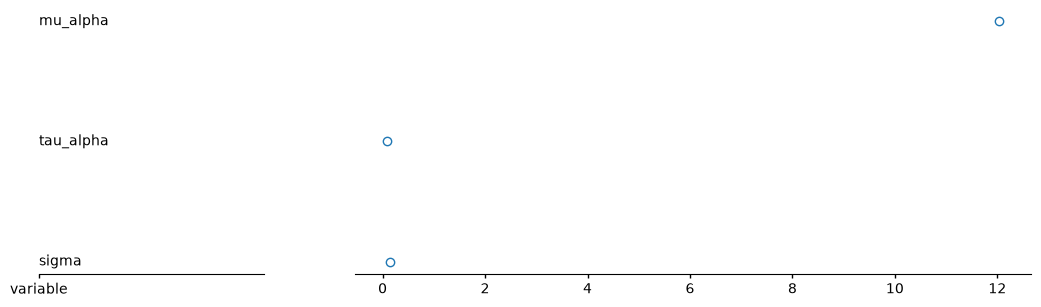

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from house_price_predictor import build_feature_frame, load_housing_data, train_val_split, rmse, r2_score
from house_price_predictor.hierarchical import fit_hierarchical_neighborhood, hierarchical_predict_mean
import arviz as az

train, _ = load_housing_data()
# Use a compact numeric feature set for faster sampling
cols = ["OverallQual", "GrLivArea", "YearBuilt", "TotalBsmtSF", "GarageCars"]
sub = train.dropna(subset=cols + ["SalePrice", "Neighborhood"]).copy()
sub = sub.loc[sub["GrLivArea"] <= 4000]
rng = np.random.default_rng(0)
idx = rng.choice(len(sub), size=min(600, len(sub)), replace=False)
sub = sub.iloc[idx]
X = sub[cols].to_numpy(dtype=float)
y = np.log1p(sub["SalePrice"].to_numpy(dtype=float))
neigh = sub["Neighborhood"].to_numpy()
# hold-out split
perm = rng.permutation(len(y))
n_val = int(0.2 * len(y))
va, tr = perm[:n_val], perm[n_val:]

idata, model, meta = fit_hierarchical_neighborhood(
    X[tr], y[tr], neigh[tr], draws=600, tune=600, chains=2
)
pred = hierarchical_predict_mean(idata, X[va], neigh[va], meta)
print(f"Val RMSE={rmse(y[va], pred):.4f}  R²={r2_score(y[va], pred):.4f}")
print("Posterior mean τ_α (neighborhood shrink):", float(idata.posterior["tau_alpha"].mean()))
az.plot_forest(idata, var_names=["mu_alpha", "tau_alpha", "sigma"], combined=True)
plt.savefig(ROOT / "artifacts" / "hierarchical_forest.png", dpi=120)
plt.show()
